# G배수지에서 나가는 물 예측
**유출유량 시계열 데이터에 슬라이딩 윈도우 기법을 이용한 LSTM**
- 27일 학습, 다음 1일 예측.

**Savitzky-Golay Filter를 사용하여 데이터를 부드럽게 전처리**
- 본래 삐죽빼죽거리는 signal 데이터를 부드럽게 만들기위해 사용하는 필터.
- 윈도우를 슬라이딩하면서 윈도우 안의 데이터를 low degree 다항식에 fitting해서 전처리.

In [1]:
import numpy as np
import torch
import torch.nn as nn  
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

In [2]:
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
import scipy
print(f"scipy: {scipy.__version__}")
print(f"torch: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

numpy: 1.26.4
pandas: 2.1.4
scipy: 1.12.0
torch: 2.2.0+cu121
Using device: cuda


**Params**

In [780]:
#data slicing
start = 1440 * 1 # +1일차
if (start != 0):
    start = start-2
end = start + 1440 * 5 #일간
split_rate = 1 - 1/5 

#Sliding window config
window_size=120
forecast_size=30
lead_time=1 #forecast_size 보다 커지면 윈도우 사이에 갭이 생기므로 주의

#LSTM config
units = 64

#learning config
epochs=10
batch_size=64
lr=0.01 # < 0.08
dropout=0.3

In [781]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

**2일차부터 시작해서 28일분의 데이터를 사용하여 학습 및 예측할 예정**

In [782]:
g_resv_flow_temp = g_resv_flow[start:end]

time = g_resv_flow_temp['time']
time = pd.to_datetime(time)
g_resv_flow_temp['time'] = time

g_resv_flow_temp.head()


C:\Users\user\AppData\Local\Temp\ipykernel_18304\3718589298.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_resv_flow_temp['time'] = time


,time,g_resv_flow
1438,2023-01-02 00:01:00,23
1439,2023-01-02 00:02:00,24
1440,2023-01-02 00:03:00,22
1441,2023-01-02 00:04:00,24
1442,2023-01-02 00:05:00,22


**Preprocessing (Savitzky-Golay Filter)**
- https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter 의 gif 참고
- 삐죽거리는 데이터를 스무스하게 만들어주는 전처리 방식 
- 슬라이딩 윈도우 기법으로 윈도우 프레임 안에 있는 데이터들을 low-degree polynomial 그래프에 맞춰서 전처리 해준다. 
- savgol_filter(data, window_length=윈도우 너비, polyorder=다항식 차수)
- 아래는 2차 다항식을 이용했다. 그래프에 작은 포물선들이 보일 것.

In [783]:
g_resv_flow_temp['savgol_smooth'] = savgol_filter(g_resv_flow_temp['g_resv_flow'], window_length=31, polyorder=1)

C:\Users\user\AppData\Local\Temp\ipykernel_18304\1935789530.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_resv_flow_temp['savgol_smooth'] = savgol_filter(g_resv_flow_temp['g_resv_flow'], window_length=31, polyorder=1)


**Data Visualization After Processing**

In [784]:
#fig, ax = plt.subplots(figsize=(15,5))

#=========g_resv_flow
#=========g_resv_flow
#=========g_resv_flow
#ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
#ax.plot(time, g_resv_flow_temp['savgol_smooth'], label='savgol applied', color='blue')

#=========misc config
#=========misc config
#=========misc config
#ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#ax.set_xlabel('lunch time')
#ax.set_ylabel('G-resv flow')
#ax.legend()

#plt.xticks(rotation=45)

#plt.show()

**Normalization**

In [785]:
scaler = MinMaxScaler(feature_range=(0,1))

column_to_normalize = g_resv_flow_temp.columns[-1]
g_resv_flow_temp['normalized_flow'] = scaler.fit_transform(g_resv_flow_temp[[column_to_normalize]])

C:\Users\user\AppData\Local\Temp\ipykernel_18304\2565260159.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_resv_flow_temp['normalized_flow'] = scaler.fit_transform(g_resv_flow_temp[[column_to_normalize]])


**Create Sliding Window Dataset**
- 슬라이딩 윈도우 코드를 수정했습니다. 기존에 1분씩 윈도우를 밀던걸 lead_time이라는 변수를 지정하여 그만큼 밀어내도록 합니다. 과적합을 방지하기 위해 작성해보았습니다. 
- 2026/01/30 오후 기준: 다시 기존 1분씩 윈도우를 밀고있습니다.

In [786]:
# X.shape = (60,1) y.shape = (10,1) => X는 60분 학습 데이터, y는 10분 예측 데이터. 1분이 1개의 feature로 들어간다.  
def create_sliding_windows(data, window_size=60, lead_time=1, forecast_size=10):
    #기존 분단위 슬라이딩 코드
    stop_index = len(data) - window_size - forecast_size# -lead_time
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [data[i+window_size : i+window_size+forecast_size] for i in range(stop_index)]
    
    #신규 lead_time분단위 슬라이딩 코드: 윈도우를 1분씩 뒤로 미는 것이 아니라 x분씩 뒤로 민다. 과도한 학습을 방지하기 위해 작성해보았음.
    #stop_index = int((len(data) - window_size - forecast_size)/lead_time)
    #X = [data[i*lead_time : i*lead_time+window_size] for i in range(stop_index)]
    #y = [data[i*lead_time+window_size : i*lead_time+window_size+forecast_size] for i in range(stop_index)]

    return np.array(X), np.array(y)

data = g_resv_flow_temp['normalized_flow'].values
X,y = create_sliding_windows(data=data, window_size=window_size, lead_time=lead_time, forecast_size=forecast_size)
X = X.reshape((X.shape[0], X.shape[1],1))

In [787]:
stop_index = int(len(data) - window_size - forecast_size)
len(data)
stop_index, X.shape, y.shape

(7050, (7050, 120, 1), (7050, 30))

**Train Test Split**

In [788]:
1440*4

5760

In [789]:
split_index = int(len(X) * split_rate)
print(split_index)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

5640


In [790]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5640, 120, 1), (1410, 120, 1), (5640, 30), (1410, 30))

**Convert Train-Test Dataset into Tensor**

In [791]:
X_train, X_test, y_train, y_test = torch.FloatTensor(X_train), torch.FloatTensor(X_test), torch.FloatTensor(y_train), torch.FloatTensor(y_test)

**Create Model Class**

In [792]:
class FlowPredictor(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=units, output_dim=forecast_size, dropout=dropout):
        super(FlowPredictor, self).__init__()
        #Layer1
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        #Layer2
        self.lstm2 = nn.LSTM(hidden_dim, hidden_dim // 2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        #Layer3
        self.lstm3 = nn.LSTM(hidden_dim // 2, hidden_dim // 4, batch_first=True)
        self.dropout3 = nn.Dropout(dropout)

        #Last layer
        self.fc = nn.Linear(hidden_dim // 4, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm1_out, _ = self.lstm1(x)
        out = self.dropout1(lstm1_out)

        lstm2_out, _ = self.lstm2(lstm1_out)
        out = self.dropout2(lstm2_out)

        lstm3_out, _ = self.lstm3(lstm2_out)

        # Use the last hidden state for prediction
        last_hidden = lstm3_out[:, -1, :]
        out = self.dropout3(last_hidden)
        out = self.fc(out)
        return out

**Execute Learning**
- torch를 적용하여 학습코드 새로 작성 (2026/01/29)
- CUDA를 이용하도록 train/test 데이터를 DataLoader로 wrapping
- 한번에 1-batch_size만큼의 데이터를 GPU메모리에 올려서 연산하도록 코드 수정

In [793]:
#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#Move the model and train/test data to CUDA
model = FlowPredictor().to(device)

# Wrap tensors into a Dataset object
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#mse_criterion = nn.MSELoss() # For MSE
mae_criterion = nn.L1Loss() # Equivalent to mean_absolute_error
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#Learning
for epoch in range(epochs):
    model.train()

    running_train_loss = 0.0
    #Train
    for batch_X, batch_y in train_loader:
        # Move batch to CUDA
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass (Batch level)
        outputs = model(batch_X)
        loss = mae_criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avg_mae_train = running_train_loss / len(train_loader)
    
    # Validation
    all_preds = []
    all_tests = []

    model.eval()
    total_mae_val = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Move ONLY the small batch to the GPU
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)

            loss = mae_criterion(outputs, batch_y)
            total_mae_val += loss.item()

            # Move back to CPU and convert to list/numpy
            all_preds.append(outputs.cpu())
            all_tests.append(batch_y.cpu())

    average_mae_val = total_mae_val / len(test_loader)
    if(epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], MAE Loss: {avg_mae_train:.4f}, MAE Val Loss: {average_mae_val:.4f}')

# Concatenate all batches into a single numpy array
y_pred_np = torch.cat(all_preds).numpy()
y_test_np = torch.cat(all_tests).numpy()

Epoch [5/10], MAE Loss: 0.0461, MAE Val Loss: 0.0353
Epoch [10/10], MAE Loss: 0.0432, MAE Val Loss: 0.0379


**Recover Original Scale (Denormalize)**

In [794]:
y_pred_original = scaler.inverse_transform(y_pred_np.reshape(-1,1)).reshape(y_pred_np.shape)
y_test_original = scaler.inverse_transform(y_test_np.reshape(-1,1)).reshape(y_test_np.shape)

**Evaluation**

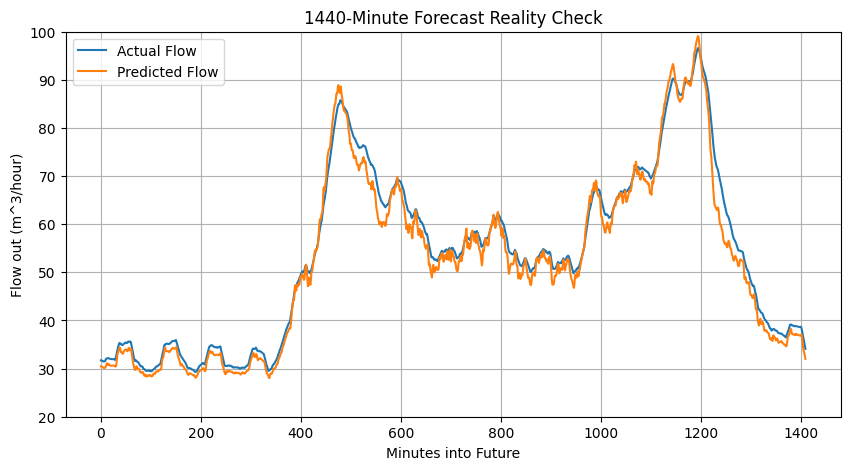

In [797]:
sample_idx0 = 1440 * 0
interval = 60*24 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval

y_test_flattened = y_test_original[:,0].flatten()
y_test_plot = y_test_flattened[sample_idx0 : sample_idx1]

y_pred_flattened = y_pred_original[:,0].flatten()
y_pred_plot = y_pred_flattened[sample_idx0 : sample_idx1]

plt.figure(figsize=(10, 5))


plt.plot(range(len(y_test_plot)), y_test_plot, label='Actual Flow')#, marker='o')
plt.plot(range(len(y_pred_plot)), y_pred_plot, label='Predicted Flow')#, marker='x')

plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()

**Data Export**

In [ ]:
y_pred_export = np.concatenate( (y_pred_flattened, y_pred_original[-1]))

g_resv_flow_export = g_resv_flow_temp[-1440:]

y_accuracy = (1-np.abs(y_pred_original - y_test_original) / (y_test_original+1))
y_accuracy_export = np.concatenate((y_accuracy[:,0], y_accuracy[-1]))

(1440,)

In [ ]:
del g_resv_flow_export['savgol_smooth']
del g_resv_flow_export['normalized_flow']
del g_resv_flow_export['g_resv_flow']
g_resv_flow_export['g_resv_flow_pred'] = y_pred_export
g_resv_flow_export['accuracy'] = y_accuracy_export

In [844]:
type(g_resv_flow_export)
g_resv_flow_export[:2]

,time,g_resv_flow_pred,accuracy
7198,2023-01-06 00:05:00,30.467293,0.962018
7199,2023-01-06 00:06:00,30.467098,0.962962


In [839]:
import json

# 1. Convert the DataFrame rows to a list of dictionaries
json_data = g_resv_flow_export.to_json(orient='records', date_format='iso')

# 2. Parse that string back to a Python object and wrap it
# (This step is necessary if you want the 'predictions' header)
final_dict = {
    "predictions": json.loads(json_data)
}

# 3. Convert the final dictionary to a JSON string for Redis
json_for_redis = json.dumps(final_dict)

In [843]:
json_for_redis

'{"predictions": [{"time": "2023-01-06T00:05:00.000", "g_resv_flow_pred": 30.4672927856, "accuracy": 0.9620178342}, {"time": "2023-01-06T00:06:00.000", "g_resv_flow_pred": 30.4670982361, "accuracy": 0.9629615545}, {"time": "2023-01-06T00:07:00.000", "g_resv_flow_pred": 30.3768157959, "accuracy": 0.9601987004}, {"time": "2023-01-06T00:08:00.000", "g_resv_flow_pred": 30.3127384186, "accuracy": 0.9610840082}, {"time": "2023-01-06T00:09:00.000", "g_resv_flow_pred": 30.2506008148, "accuracy": 0.9601274729}, {"time": "2023-01-06T00:10:00.000", "g_resv_flow_pred": 30.1731529236, "accuracy": 0.9596501589}, {"time": "2023-01-06T00:11:00.000", "g_resv_flow_pred": 30.1098880768, "accuracy": 0.9586546421}, {"time": "2023-01-06T00:12:00.000", "g_resv_flow_pred": 30.0892848969, "accuracy": 0.9561188817}, {"time": "2023-01-06T00:13:00.000", "g_resv_flow_pred": 30.1817302704, "accuracy": 0.958011508}, {"time": "2023-01-06T00:14:00.000", "g_resv_flow_pred": 30.316280365, "accuracy": 0.9592931867}, {"ti

In [845]:
from redis import Redis

try:
    r = Redis(host='10.125.121.184', port=6379)
    print("연결 시도 중...")
    if r.ping():
        print("연결 성공! (PONG)")
except Exception as e:
    print(f"연결 실패: {e}")

연결 시도 중...
연결 성공! (PONG)
